# Setup

In [5]:
from google.colab import userdata

GIT_TOKEN = userdata.get('GH_TOKEN')
REPO_URL = f"https://{GIT_TOKEN}@github.com/Vlad-Andres/HCML-project.git"

!rm -rf temp_repo
!git clone {REPO_URL} temp_repo
!cp -r temp_repo/* .
!rm -rf temp_repo
!ls -F

Cloning into 'temp_repo'...
remote: Enumerating objects: 147, done.
remote: Counting objects: 100% (147/147), done.
remote: Compressing objects: 100% (119/119), done.
remote: Total 147 (delta 47), reused 122 (delta 25), pack-reused 0 (from 0)
Receiving objects: 100% (147/147), 18.85 MiB | 18.51 MiB/s, done.
Resolving deltas: 100% (47/47), done.
HCML_Proj_OULAD.ipynb  oulad_outputs/  sample_data/
original.py	       README.md       src/


In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.inspection import permutation_importance, PartialDependenceDisplay
from pathlib import Path
import itertools
from src.modeling import get_xy
from src.config import (
    RANDOM_STATE,
    SHAP_SAMPLE_SIZE_TREE,
    SHAP_SAMPLE_SIZE_SUBGROUP,
    SHAP_TOP_N_FEATURES,
    SHAP_SUMMARY_MAX_DISPLAY,
    PERMUTATION_N_REPEATS,
    PFI_TOP_N,
    PLOT_DPI,
    PLOT_DPI_TEMP,
    HISTOGRAM_BINS,
    HISTOGRAM_ALPHA,
)
import shap as shap_lib

def save_figure_to_output_dir(fig, filename, output_dir, dpi=None):
    if output_dir is not None:
        path = Path(output_dir) / filename
        fig.savefig(path, dpi=dpi or PLOT_DPI, bbox_inches="tight")
        print("Saved:", path)

def _sample_data(X, sample_size, random_state=RANDOM_STATE):
    if len(X) > sample_size:
        return X.sample(n=sample_size, random_state=random_state)
    return X

def get_feature_names_from_pipeline(pipe):
    prep = pipe.named_steps["prep"]
    feature_names = []
    for name, transformer, cols in prep.transformers_:
        if name == "remainder" and transformer == "drop":
            continue
        if hasattr(transformer, "named_steps") and "onehot" in transformer.named_steps:
            ohe = transformer.named_steps["onehot"]
            names = ohe.get_feature_names_out(cols)
            feature_names.extend(names.tolist())
        else:
            feature_names.extend(cols)
    return np.array(feature_names)

def _compute_shap_values_for_pipe(pipe, X_sample):
    model = pipe.named_steps["model"]
    prep = pipe.named_steps["prep"]
    X_trans = prep.transform(X_sample)
    if hasattr(X_trans, "toarray"): X_trans = X_trans.toarray()
    explainer = shap_lib.TreeExplainer(model)
    shap_vals = explainer.shap_values(X_trans)
    if isinstance(shap_vals, list): shap_vals = shap_vals[1]
    if len(shap_vals.shape) == 3: shap_vals = shap_vals[:, :, 1]
    feature_names = get_feature_names_from_pipeline(pipe)
    return shap_vals, feature_names

def plot_shap_distributions(models_dict, test_df, sample_size=None, output_dir=None):
    if sample_size is None: sample_size = SHAP_SAMPLE_SIZE_TREE
    X_test, _ = get_xy(test_df)
    X_sample = _sample_data(X_test, sample_size, RANDOM_STATE)
    shap_data = {}
    for model_name, pipe in models_dict.items():
        if hasattr(pipe.named_steps["model"], "feature_importances_"):
            shap_vals, feature_names = _compute_shap_values_for_pipe(pipe, X_sample)
            shap_data[model_name] = (shap_vals, feature_names)
    for model_a, model_b in itertools.combinations(shap_data.keys(), 2):
        vals_a, names_a = shap_data[model_a]
        vals_b, _ = shap_data[model_b]
        top_indices = np.argsort(np.abs(vals_a).mean(axis=0))[-6:][::-1]
        fig, axes = plt.subplots(6, 1, figsize=(10, 15))
        for i, idx in enumerate(top_indices):
            axes[i].hist(vals_a[:, idx].ravel(), alpha=HISTOGRAM_ALPHA, label=model_a, bins=HISTOGRAM_BINS)
            axes[i].hist(vals_b[:, idx].ravel(), alpha=HISTOGRAM_ALPHA, label=model_b, bins=HISTOGRAM_BINS)
            axes[i].set_title(names_a[idx])
            axes[i].legend()
        plt.tight_layout()
        save_figure_to_output_dir(fig, f"shap_compare_{model_a}_{model_b}.png", output_dir)
        plt.show()

In [ ]:
# from google.colab import drive
# drive.mount('/content/drive')

# Load data

In [7]:
DATA_DIR = data_loader.resolve_data_dir()
OUTPUT_DIR = Path("/content/oulad_outputs") if Path("/content").exists() else Path("oulad_outputs")
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)
tables = data_loader.load_all_tables(DATA_DIR)
data_loader.inspect_tables(tables["student_info"], tables["courses"])

Using Colab cache for faster access to the 'student-demographics-online-education-dataoulad' dataset.
Downloaded dataset to: /kaggle/input/student-demographics-online-education-dataoulad
Reading courses.csv from /kaggle/input/student-demographics-online-education-dataoulad/courses.csv
Reading assessments.csv from /kaggle/input/student-demographics-online-education-dataoulad/assessments.csv
Reading studentAssessment.csv from /kaggle/input/student-demographics-online-education-dataoulad/studentAssessment.csv
Reading studentInfo.csv from /kaggle/input/student-demographics-online-education-dataoulad/studentInfo.csv
Reading studentRegistration.csv from /kaggle/input/student-demographics-online-education-dataoulad/studentRegistration.csv
Reading studentVle.csv from /kaggle/input/student-demographics-online-education-dataoulad/studentVle.csv
Reading vle.csv from /kaggle/input/student-demographics-online-education-dataoulad/vle.csv

Shapes:
  courses: (22, 3)
  assessments: (206, 6)
  student_

In [8]:
base = feature_engineering.build_base_table(tables["student_info"], tables["courses"])
early_df = feature_engineering.build_dataset_for_stage(
    base, tables["student_vle"], tables["vle"], tables["courses"],
    tables["student_assess"], tables["assessments"], tables["student_reg"],
    fraction=0.25, stage_name="early_25pct"
)
full_df = feature_engineering.build_dataset_for_stage(
    base, tables["student_vle"], tables["vle"], tables["courses"],
    tables["student_assess"], tables["assessments"], tables["student_reg"],
    fraction=1.00, stage_name="full_100pct"
)
display(early_df.head()); display(full_df.head())


Base table shape: (32593, 14)
Target distribution:
target_unsuccessful
1    17208
0    15385
Name: count, dtype: int64
target_unsuccessful
1    0.527966
0    0.472034
Name: proportion, dtype: float64

Building dataset for early_25pct, fraction=0.25
VLE features: (28360, 18)
Assessment features: (25444, 11)
Registration features: (32593, 6)
Final stage table: (32593, 39)

Building dataset for full_100pct, fraction=1.0
VLE features: (28500, 18)
Assessment features: (25843, 11)
Registration features: (32593, 6)
Final stage table: (32593, 39)


,code_module,code_presentation,id_student,target_unsuccessful,module_presentation_length,gender,age_band,highest_education,imd_band,region,num_of_prev_attempts,studied_credits,date_registration,registered_before_start,days_registered_before_start,vle_total_clicks,vle_active_days,vle_mean_clicks_per_record,vle_max_clicks_per_record,vle_num_records,vle_clicks_per_active_day,clicks_forumng,clicks_homepage,clicks_other_activity,clicks_oucontent,clicks_ouwiki,clicks_quiz,clicks_resource,clicks_subpage,clicks_url,assess_num_submitted,assess_mean_score,assess_min_score,assess_max_score,assess_weighted_score_sum,assess_total_weight_seen,assess_late_rate,assess_mean_days_before_due,stage
0,AAA,2013J,11391,0,268,M,55<=,HE Qualification,90-100%,East Anglian Region,0,240,-159.0,1.0,159.0,447.0,18.0,5.518519,76.0,81.0,24.833333,96.0,63.0,0.0,266.0,0.0,0.0,9.0,12.0,1.0,2.0,81.5,78.0,85.0,24.8,30.0,0.0,1.0,early_25pct
1,AAA,2013J,28400,0,268,F,35-55,HE Qualification,20-30%,Scotland,0,60,-53.0,1.0,53.0,508.0,22.0,3.479452,19.0,146.0,23.090909,181.0,114.0,0.0,148.0,0.0,0.0,0.0,39.0,26.0,2.0,69.0,68.0,70.0,20.6,30.0,0.5,-0.5,early_25pct
2,AAA,2013J,30268,1,268,F,35-55,A Level or Equivalent,30-40%,North Western Region,0,60,-92.0,1.0,92.0,179.0,6.0,4.261905,23.0,42.0,29.833333,87.0,27.0,0.0,52.0,0.0,0.0,0.0,10.0,3.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,early_25pct
3,AAA,2013J,31604,0,268,F,35-55,A Level or Equivalent,50-60%,South East Region,0,60,-52.0,1.0,52.0,710.0,38.0,3.212670,13.0,221.0,18.684211,205.0,159.0,0.0,250.0,0.0,0.0,1.0,59.0,36.0,2.0,71.5,71.0,72.0,21.4,30.0,0.0,2.5,early_25pct
4,AAA,2013J,32885,0,268,F,0-35,Lower Than A Level,50-60%,West Midlands Region,0,60,-176.0,1.0,176.0,313.0,21.0,3.226804,19.0,97.0,14.904762,65.0,59.0,0.0,174.0,0.0,0.0,0.0,12.0,3.0,1.0,69.0,69.0,69.0,6.9,10.0,1.0,-7.0,early_25pct


,code_module,code_presentation,id_student,target_unsuccessful,module_presentation_length,gender,age_band,highest_education,imd_band,region,num_of_prev_attempts,studied_credits,date_registration,registered_before_start,days_registered_before_start,vle_total_clicks,vle_active_days,vle_mean_clicks_per_record,vle_max_clicks_per_record,vle_num_records,vle_clicks_per_active_day,clicks_forumng,clicks_homepage,clicks_other_activity,clicks_oucontent,clicks_ouwiki,clicks_quiz,clicks_resource,clicks_subpage,clicks_url,assess_num_submitted,assess_mean_score,assess_min_score,assess_max_score,assess_weighted_score_sum,assess_total_weight_seen,assess_late_rate,assess_mean_days_before_due,stage
0,AAA,2013J,11391,0,268,M,55<=,HE Qualification,90-100%,East Anglian Region,0,240,-159.0,1.0,159.0,836.0,39.0,4.518919,76.0,185.0,21.435897,191.0,131.0,0.0,475.0,0.0,0.0,13.0,21.0,5.0,5.0,82.0,78.0,85.0,82.4,100.0,0.0,1.8,full_100pct
1,AAA,2013J,28400,0,268,F,35-55,HE Qualification,20-30%,Scotland,0,60,-53.0,1.0,53.0,1220.0,73.0,3.253333,23.0,375.0,16.712329,344.0,278.0,10.0,476.0,0.0,0.0,7.0,64.0,41.0,5.0,66.4,60.0,70.0,65.4,100.0,0.4,0.0,full_100pct
2,AAA,2013J,30268,1,268,F,35-55,A Level or Equivalent,30-40%,North Western Region,0,60,-92.0,1.0,92.0,179.0,6.0,4.261905,23.0,42.0,29.833333,87.0,27.0,0.0,52.0,0.0,0.0,0.0,10.0,3.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,full_100pct
3,AAA,2013J,31604,0,268,F,35-55,A Level or Equivalent,50-60%,South East Region,0,60,-52.0,1.0,52.0,1989.0,118.0,3.182400,22.0,625.0,16.855932,605.0,402.0,2.0,758.0,0.0,0.0,10.0,125.0,87.0,5.0,76.0,71.0,88.0,76.3,100.0,0.0,2.0,full_100pct
4,AAA,2013J,32885,0,268,F,0-35,Lower Than A Level,50-60%,West Midlands Region,0,60,-176.0,1.0,176.0,739.0,62.0,2.583916,19.0,286.0,11.919355,121.0,152.0,2.0,353.0,0.0,0.0,38.0,62.0,11.0,5.0,54.4,30.0,75.0,55.0,100.0,1.0,-11.4,full_100pct


In [9]:
train_students, test_students = modeling.student_train_test_split(base)
early_train, early_test = modeling.apply_split(early_df, train_students, test_students)
full_train,  full_test  = modeling.apply_split(full_df,  train_students, test_students)
perf_early, models_early = modeling.fit_and_evaluate_stage("early_25pct", early_train, early_test)
perf_full,  models_full  = modeling.fit_and_evaluate_stage("full_100pct", full_train, full_test)
performance_table = pd.concat([perf_early, perf_full], ignore_index=True)[[
    "stage", "model", "accuracy", "balanced_accuracy",
    "precision_at_risk", "recall_at_risk", "f1_at_risk", "roc_auc"
]]
display(performance_table.sort_values(["model", "stage"]))

GPU detected! XGBoost will use GPU acceleration.
Training LogisticRegression for early_25pct...
Training RandomForest for early_25pct...
Training XGBoost for early_25pct...
GPU detected! XGBoost will use GPU acceleration.
Training LogisticRegression for full_100pct...
Training RandomForest for full_100pct...
Training XGBoost for full_100pct...


,stage,model,accuracy,balanced_accuracy,precision_at_risk,recall_at_risk,f1_at_risk,roc_auc
0,early_25pct,LogisticRegression,0.786486,0.789048,0.835087,0.740784,0.785114,0.874960
3,full_100pct,LogisticRegression,0.923956,0.924833,0.945132,0.908306,0.926353,0.974703
1,early_25pct,RandomForest,0.812039,0.814817,0.864550,0.762483,0.810315,0.893265
4,full_100pct,RandomForest,0.943366,0.944965,0.976102,0.914839,0.944478,0.983874
2,early_25pct,XGBoost,0.811057,0.813073,0.852669,0.775082,0.812026,0.894142
5,full_100pct,XGBoost,0.947174,0.948372,0.972549,0.925805,0.948601,0.986410


# Analysis

## Fairness

,stage,model,sensitive_attr,group,n,base_rate_true_at_risk,accuracy,balanced_accuracy,precision_at_risk,recall_at_risk,f1_at_risk,tp,tn,fp,fn,tpr_recall_at_risk,fpr,fnr,tnr,selection_rate_pred_at_risk,roc_auc
0,early_25pct,LogisticRegression,gender,F,3696,0.521916,0.771374,0.774487,0.832515,0.703473,0.762574,1357,1494,273,572,0.703473,0.154499,0.296527,0.845501,0.441017,0.861029
1,early_25pct,LogisticRegression,gender,M,4444,0.530378,0.799055,0.800849,0.837017,0.771319,0.802826,1818,1733,354,539,0.771319,0.169621,0.228681,0.830379,0.488749,0.886339
2,early_25pct,LogisticRegression,age_band,0-35,5778,0.544998,0.787816,0.790354,0.834202,0.762147,0.796548,2400,2152,477,749,0.762147,0.181438,0.237853,0.818562,0.497923,0.879975
3,early_25pct,LogisticRegression,age_band,35-55,2302,0.482624,0.784101,0.780741,0.838852,0.684068,0.753594,760,1045,146,351,0.684068,0.122586,0.315932,0.877414,0.393571,0.860470
4,early_25pct,LogisticRegression,age_band,55<=,60,0.433333,0.750000,0.729638,0.789474,0.576923,0.666667,15,30,4,11,0.576923,0.117647,0.423077,0.882353,0.316667,0.877828
5,early_25pct,LogisticRegression,imd_band,0-10%,866,0.650115,0.777136,0.753152,0.825704,0.833037,0.829355,469,204,99,94,0.833037,0.326733,0.166963,0.673267,0.655889,0.865706
6,early_25pct,LogisticRegression,imd_band,10-20,856,0.601636,0.788551,0.782658,0.832669,0.811650,0.822026,418,257,84,97,0.811650,0.246334,0.188350,0.753666,0.586449,0.866532
7,early_25pct,LogisticRegression,imd_band,20-30%,918,0.586057,0.785403,0.795275,0.876380,0.737918,0.801211,397,324,56,141,0.737918,0.147368,0.262082,0.852632,0.493464,0.879192
8,early_25pct,LogisticRegression,imd_band,30-40%,920,0.527174,0.782609,0.786112,0.843373,0.721649,0.777778,350,370,65,135,0.721649,0.149425,0.278351,0.850575,0.451087,0.872080
9,early_25pct,LogisticRegression,imd_band,40-50%,832,0.540865,0.784856,0.788848,0.843038,0.740000,0.788166,333,320,62,117,0.740000,0.162304,0.260000,0.837696,0.474760,0.876899


,stage,model,sensitive_attr,num_groups_included,min_group_size,max_group_size,selection_rate_pred_at_risk_gap,selection_rate_pred_at_risk_min,selection_rate_pred_at_risk_max,tpr_recall_at_risk_gap,tpr_recall_at_risk_min,tpr_recall_at_risk_max,fpr_gap,fpr_min,fpr_max,fnr_gap,fnr_min,fnr_max,accuracy_gap,accuracy_min,accuracy_max,balanced_accuracy_gap,balanced_accuracy_min,balanced_accuracy_max,f1_at_risk_gap,f1_at_risk_min,f1_at_risk_max,roc_auc_gap,roc_auc_min,roc_auc_max
0,early_25pct,LogisticRegression,age_band,3,60,5778,0.181256,0.316667,0.497923,0.185224,0.576923,0.762147,0.063791,0.117647,0.181438,0.185224,0.237853,0.423077,0.037816,0.750000,0.787816,0.060716,0.729638,0.790354,0.129882,0.666667,0.796548,0.019505,0.860470,0.879975
9,full_100pct,LogisticRegression,age_band,3,60,5778,0.092973,0.433333,0.526307,0.061448,0.900090,0.961538,0.036393,0.029412,0.065804,0.061448,0.038462,0.099910,0.045241,0.921426,0.966667,0.043583,0.922480,0.966063,0.036897,0.924642,0.961538,0.003255,0.971719,0.974974
1,early_25pct,LogisticRegression,gender,2,3696,4444,0.047732,0.441017,0.488749,0.067846,0.703473,0.771319,0.015122,0.154499,0.169621,0.067846,0.228681,0.296527,0.027680,0.771374,0.799055,0.026362,0.774487,0.800849,0.040252,0.762574,0.802826,0.025310,0.861029,0.886339
10,full_100pct,LogisticRegression,gender,2,3696,4444,0.025894,0.491883,0.517777,0.025568,0.894246,0.919813,0.011096,0.052632,0.063728,0.025568,0.080187,0.105754,0.007900,0.919643,0.927543,0.007236,0.920807,0.928043,0.010135,0.920737,0.930872,0.012087,0.967842,0.979929
2,early_25pct,LogisticRegression,imd_band,11,312,920,0.383453,0.272436,0.655889,0.256114,0.576923,0.833037,0.232647,0.094086,0.326733,0.256114,0.166963,0.423077,0.032987,0.774030,0.807018,0.078873,0.728365,0.807238,0.194434,0.634921,0.829355,0.062130,0.822578,0.884707
11,full_100pct,LogisticRegression,imd_band,11,312,920,0.307663,0.320513,0.628176,0.079175,0.855769,0.934944,0.078690,0.026882,0.105572,0.079175,0.065056,0.144231,0.032885,0.906467,0.939351,0.036155,0.901442,0.937598,0.072052,0.872549,0.944601,0.018008,0.963474,0.981481
3,early_25pct,RandomForest,age_band,3,60,5778,0.103859,0.383333,0.487193,0.080636,0.692308,0.772944,0.041265,0.105793,0.147059,0.080636,0.227056,0.307692,0.033782,0.783333,0.817116,0.041716,0.772624,0.814340,0.081537,0.734694,0.816231,0.025225,0.868778,0.894003
12,full_100pct,RandomForest,age_band,3,60,5778,0.094929,0.416667,0.511596,0.047047,0.914491,0.961538,0.028908,0.000000,0.028908,0.047047,0.038462,0.085509,0.043043,0.940291,0.983333,0.037935,0.942834,0.980769,0.036903,0.943489,0.980392,0.008163,0.977376,0.985538
4,early_25pct,RandomForest,gender,2,3696,4444,0.042285,0.441288,0.483573,0.055456,0.731985,0.787442,0.016454,0.123939,0.140393,0.055456,0.212558,0.268015,0.020466,0.800866,0.821332,0.019501,0.804023,0.823524,0.030532,0.793258,0.823791,0.020544,0.881701,0.902245
13,full_100pct,RandomForest,gender,2,3696,4444,0.017809,0.483766,0.501575,0.028020,0.899430,0.927450,0.009391,0.020604,0.029994,0.028020,0.072550,0.100570,0.018674,0.933171,0.951845,0.018705,0.934718,0.953423,0.019788,0.933549,0.953336,0.009339,0.978490,0.987829


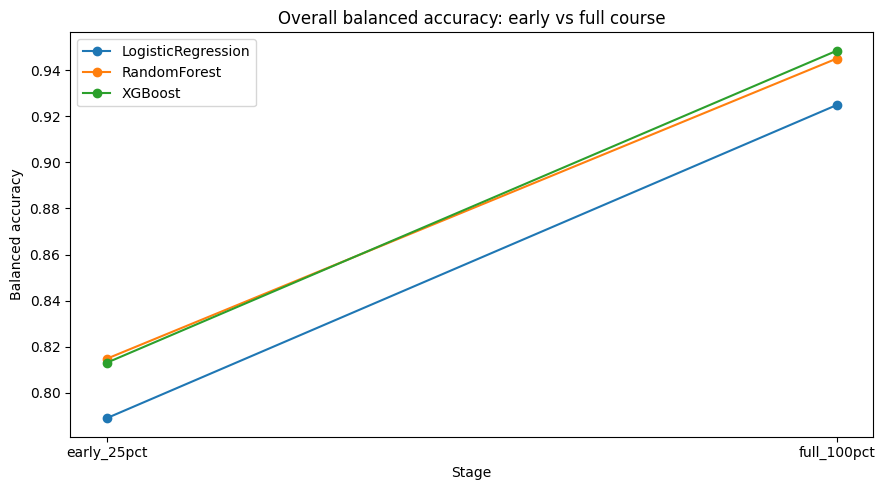

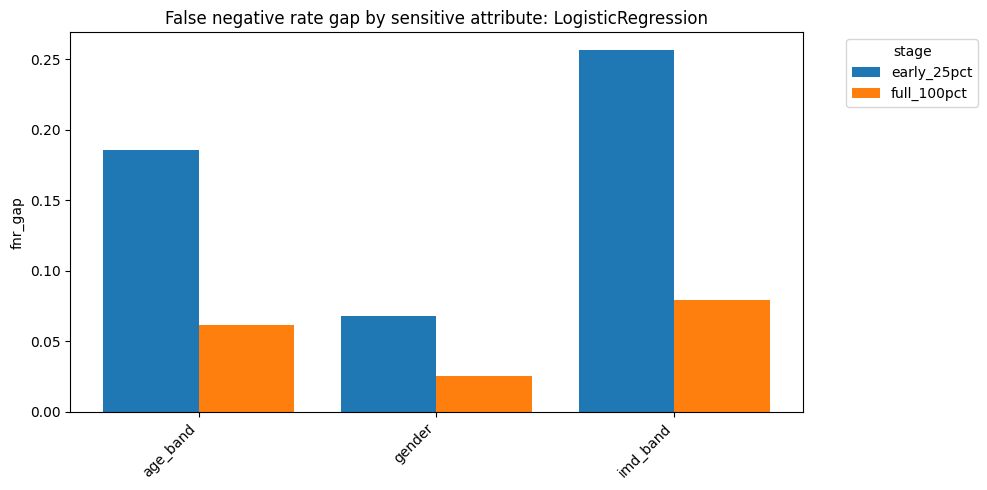

Saved: /content/oulad_outputs/fnr_gap_LogisticRegression.png


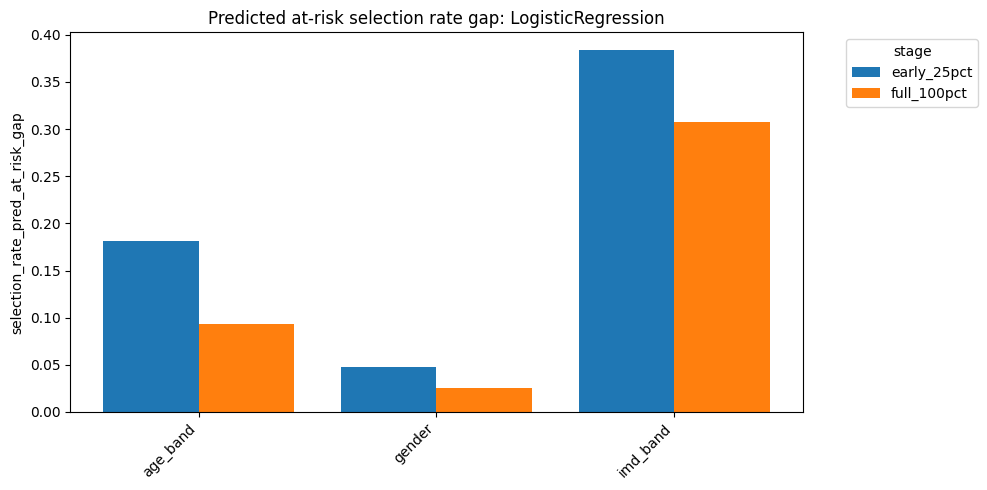

Saved: /content/oulad_outputs/selection_rate_gap_LogisticRegression.png


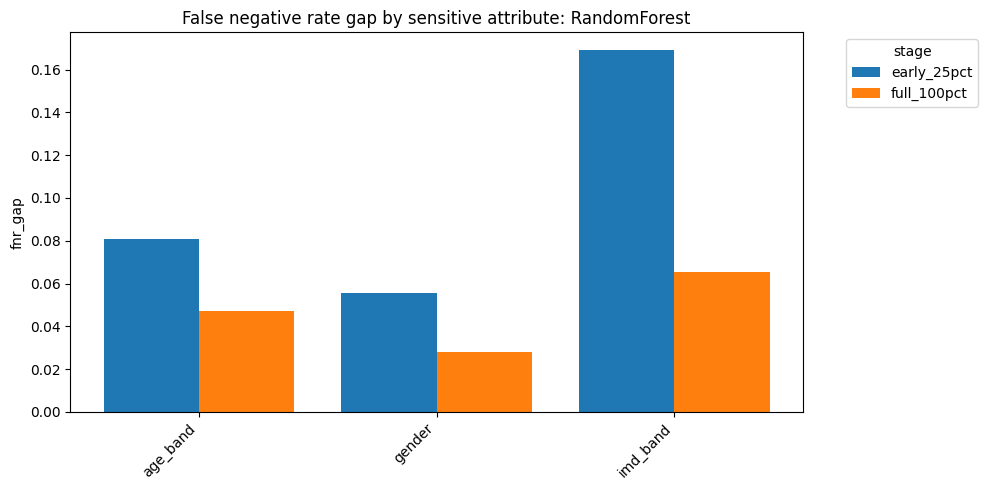

Saved: /content/oulad_outputs/fnr_gap_RandomForest.png


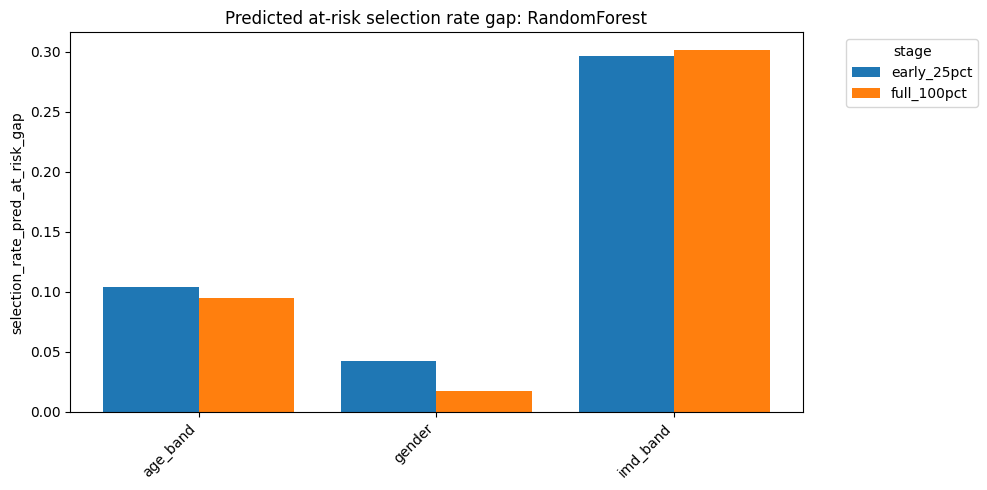

Saved: /content/oulad_outputs/selection_rate_gap_RandomForest.png


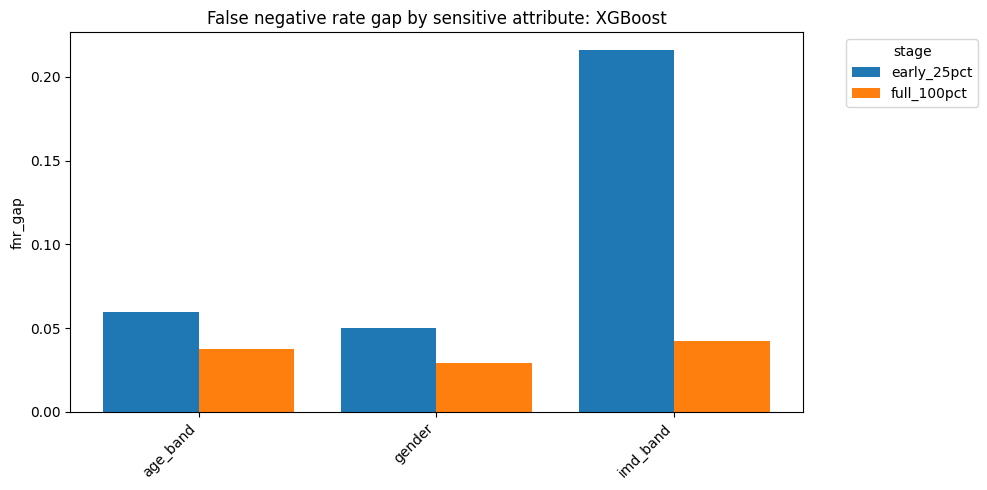

Saved: /content/oulad_outputs/fnr_gap_XGBoost.png


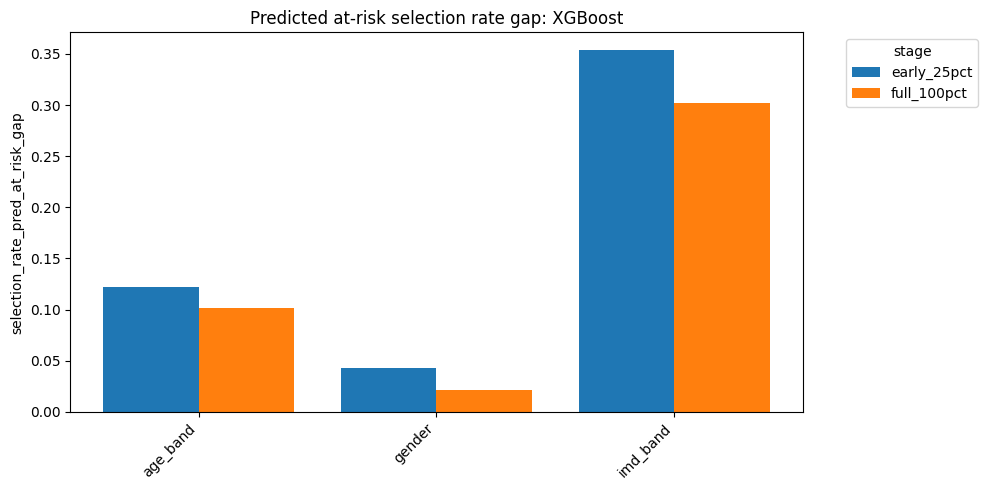

Saved: /content/oulad_outputs/selection_rate_gap_XGBoost.png


In [10]:
subgroup_early = fairness.run_fairness_analysis("early_25pct", early_test, models_early)
subgroup_full  = fairness.run_fairness_analysis("full_100pct", full_test,  models_full)
subgroup_metrics = pd.concat([subgroup_early, subgroup_full], ignore_index=True)
fairness_gaps = fairness.fairness_gap_summary(subgroup_metrics)
display(subgroup_metrics.head(30))
display(fairness_gaps.sort_values(["model", "sensitive_attr", "stage"]))

visualization.plot_overall_performance(performance_table, OUTPUT_DIR)
visualization.plot_fairness_gaps(fairness_gaps, OUTPUT_DIR)

## Explainability

In [ ]:
from src.explainability import (
    run_shap_for_tree_model,
    compute_family_importance,
    plot_family_importance,
    subgroup_shap_comparison,
    run_permutation_importance,
    run_partial_dependence,
    plot_shap_distributions
)

# plot_shap_distributions(models_early, early_test, sample_size=800, output_dir=OUTPUT_DIR)

RUN_SHAP = True
shap_results = {}
if RUN_SHAP:
    for model_name, pipe in models_early.items():
        shap_results[(model_name, "early_25pct")] = run_shap_for_tree_model(
            pipe,
            early_test,
            "early_25pct",
            model_name,
            output_dir=OUTPUT_DIR,
            shap_available=SHAP_AVAILABLE,
        )
    for model_name, pipe in models_full.items():
        shap_results[(model_name, "full_100pct")] = run_shap_for_tree_model(
            pipe,
            full_test,
            "full_100pct",
            model_name,
            output_dir=OUTPUT_DIR,
            shap_available=SHAP_AVAILABLE,
        )

family_importance = compute_family_importance(shap_results)
plot_family_importance(family_importance, output_dir=OUTPUT_DIR)

if "RandomForest" in models_early and "RandomForest" in models_full:
    if SHAP_AVAILABLE:
        subgroup_shap_comparison(
            models_early["RandomForest"],
            early_test,
            "highest_education",
            "early_25pct",
            "RandomForest",
            shap_available=SHAP_AVAILABLE,
            output_dir=OUTPUT_DIR,
        )
        subgroup_shap_comparison(
            models_early["RandomForest"],
            early_test,
            "imd_band",
            "early_25pct",
            "RandomForest",
            shap_available=SHAP_AVAILABLE,
            output_dir=OUTPUT_DIR,
        )
    else:
        print("Skipping subgroup SHAP comparison because SHAP is unavailable.")

    pfi_early = run_permutation_importance(
        models_early["RandomForest"],
        early_test,
        "early_25pct",
        "RandomForest",
        output_dir=OUTPUT_DIR,
    )
    pfi_full = run_permutation_importance(
        models_full["RandomForest"],
        full_test,
        "full_100pct",
        "RandomForest",
        output_dir=OUTPUT_DIR,
    )

    pdp_features = ["vle_total_clicks", "vle_active_days", "studied_credits"]
    valid_features_early = [f for f in pdp_features if f in early_test.columns]
    valid_features_full = [f for f in pdp_features if f in full_test.columns]

    if valid_features_early:
        run_partial_dependence(
            models_early["RandomForest"],
            early_test,
            "early_25pct",
            "RandomForest",
            valid_features_early,
            output_dir=OUTPUT_DIR,
        )
        run_partial_dependence(
            models_early["RandomForest"],
            early_test,
            "early_25pct",
            "RandomForest",
            valid_features_early,
            centered=True,
            output_dir=OUTPUT_DIR,
        )
    if valid_features_full:
        run_partial_dependence(
            models_full["RandomForest"],
            full_test,
            "full_100pct",
            "RandomForest",
            valid_features_full,
            output_dir=OUTPUT_DIR,
        )
        run_partial_dependence(
            models_full["RandomForest"],
            full_test,
            "full_100pct",
            "RandomForest",
            valid_features_full,
            centered=True,
            output_dir=OUTPUT_DIR,
        )
else:
    print("RandomForest is not available in both early and full models for extra explainability.")


In [ ]:
from src.reporting import export_tables
export_tables(performance_table, subgroup_metrics, fairness_gaps,
              family_importance=family_importance, output_dir=OUTPUT_DIR)